In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

In [ ]:
from sklearn.datasets import fetch_california_housing

In [ ]:
housing = fetch_california_housing()

data = pd.DataFrame(housing.data, columns = housing.feature_names)
data['PRICE'] = housing.target

data.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,PRICE
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [ ]:
X = data.drop('PRICE', axis = 1)
y = data['PRICE']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)

print('Training data shape:', X_train.shape)
print('Testing data shape:', X_test.shape)

Training data shape: (16512, 8)
Testing data shape: (4128, 8)


In [ ]:
model = LinearRegression()#
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
print('Mean Square Error', mse)

rmse = np.sqrt(mse)
print('Root mean Square Error', rmse)

Mean Square Error 0.5558915986952444
Root mean Square Error 0.7455813830127764


<function matplotlib.pyplot.show(close=None, block=None)>

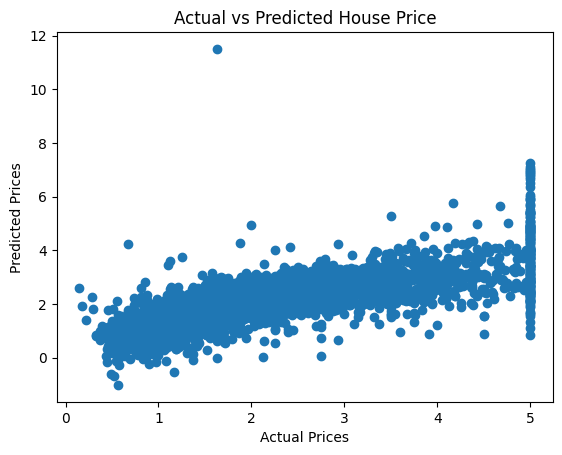

In [ ]:
plt.scatter(y_test, y_pred)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted House Price')
plt.show

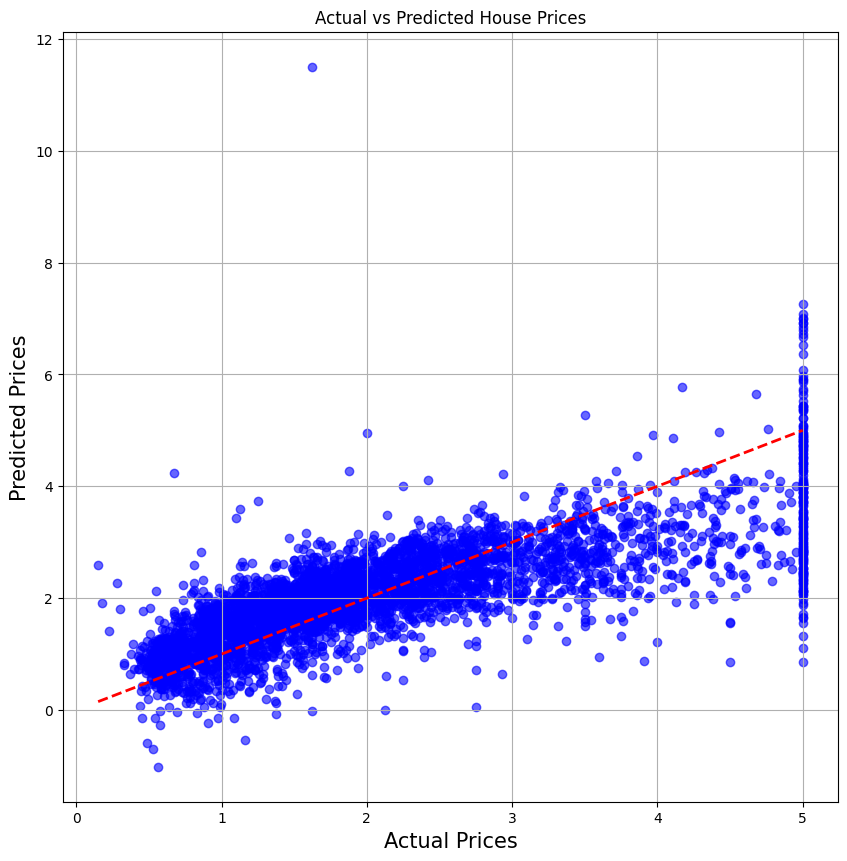

In [ ]:
plt.figure(figsize=(10,10))
plt.scatter(y_test, y_pred, c='blue', label='Predicted Prices', alpha = 0.6)
# plt.scatter(y_test, y_test, c='red', label='Actual Prices', alpha = 0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Prices', fontsize=15)
plt.ylabel('Predicted Prices', fontsize=15)
plt.title('Actual vs Predicted House Prices')
plt.grid()
plt.show()

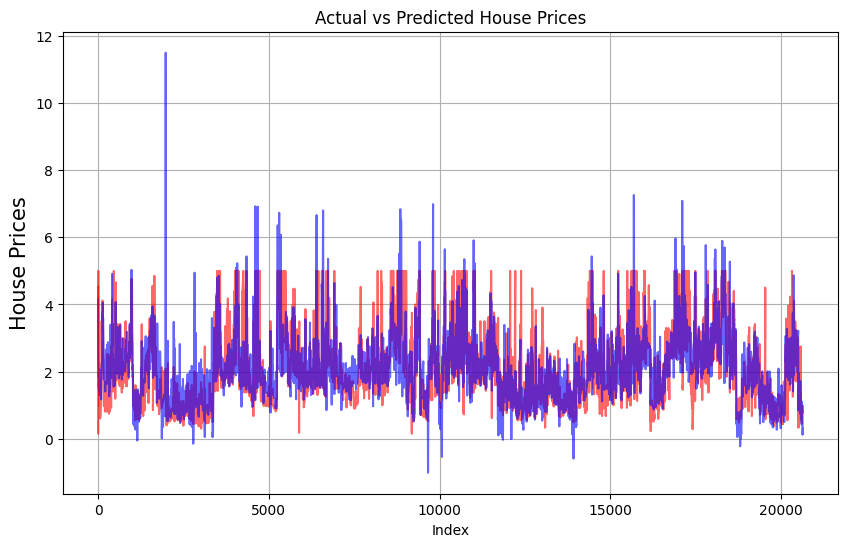

In [ ]:
results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
results.sort_index(inplace=True)

plt.figure(figsize=(10,6))
plt.plot(results.index, results['Actual'], c='red', label='Actual Prices', alpha = 0.6)
plt.plot(results.index, results['Predicted'], c='blue', label='Predicted Prices', alpha = 0.6)
plt.plot(y_test, y_test, c='red', label='Actual Prices', alpha = 0.6)
plt.xlabel('Index')
plt.ylabel('House Prices', fontsize=15)
plt.title('Actual vs Predicted House Prices')
plt.grid()
plt.show()

In [ ]:
results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})

results_sorted = results.sort_values(by = 'Actual').reset_index(drop=True)

print(results_sorted)

       Actual  Predicted
0     0.14999   2.584993
1     0.17500   1.908291
2     0.22500   1.417831
3     0.28300   2.269281
4     0.30000   1.803414
...       ...        ...
4123  5.00001   2.783743
4124  5.00001   4.278286
4125  5.00001   4.073928
4126  5.00001   3.466844
4127  5.00001   4.468770

[4128 rows x 2 columns]
